<a href="https://colab.research.google.com/github/hwangho-kim/LLM-AD/blob/master/FDC_%ED%8C%8C%EC%9A%B4%EB%8D%B0%EC%9D%B4%EC%85%98_%EB%AA%A8%EB%8D%B8_%EB%B0%8F_Few_Shot_%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install fastdtw

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp312-cp312-linux_x86_64.whl size=567861 sha256=4d9d27ae83f10f005f241a7c27e938dd4337baf8e6c0cdc184a8d073939b9ac8
  Stored in directory: /root/.cache/pip/wheels/ab/d0/26/b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw


Phase 1: 데이터 생성 및 전처리 시작...
DTW를 활용하여 비동기 Trace 데이터를 기준 궤적(SEQ_LENGTH)으로 정렬 중... (시간이 조금 소요될 수 있습니다)
-> 샘플 데이터 CSV 저장 완료 (fdc_outputs/ 폴더)
데이터 준비 완료! Pre-train: 800개, Few-shot: 20개, Test: 180개



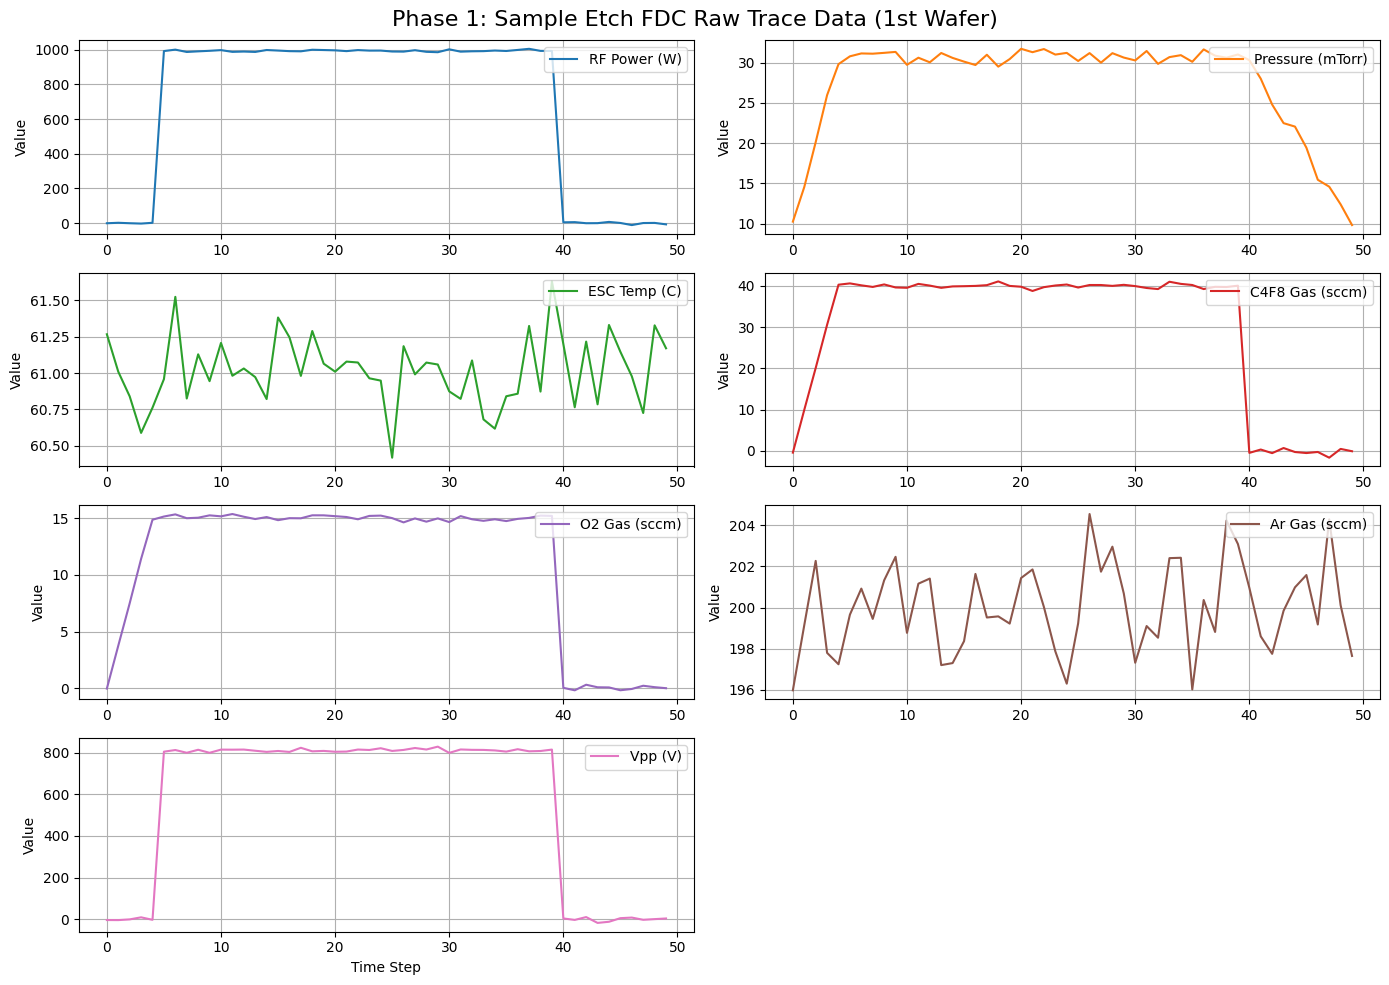

Phase 2: Foundation Model (Transformer Autoencoder) 사전 학습 시작...
Pre-train Epoch [10/30], Loss: 0.1588
Pre-train Epoch [20/30], Loss: 0.1521
Pre-train Epoch [30/30], Loss: 0.1507
Pre-training 완료 및 학습 곡선 저장 완료!



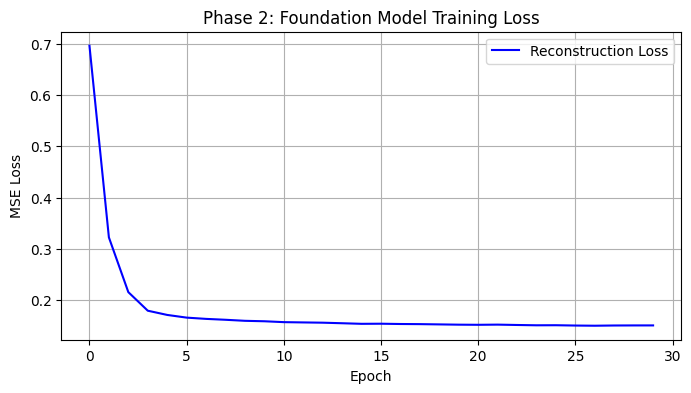

Phase 3: 소수 계측 데이터를 활용한 Foundation Model Fine-Tuning 시작...
Few-Shot Epoch [10/50], Loss: 0.0644
Few-Shot Epoch [20/50], Loss: 0.0425
Few-Shot Epoch [30/50], Loss: 0.0478
Few-Shot Epoch [40/50], Loss: 0.0456
Few-Shot Epoch [50/50], Loss: 0.0425
Few-Shot Fine-tuning 완료 및 학습 곡선 저장 완료!



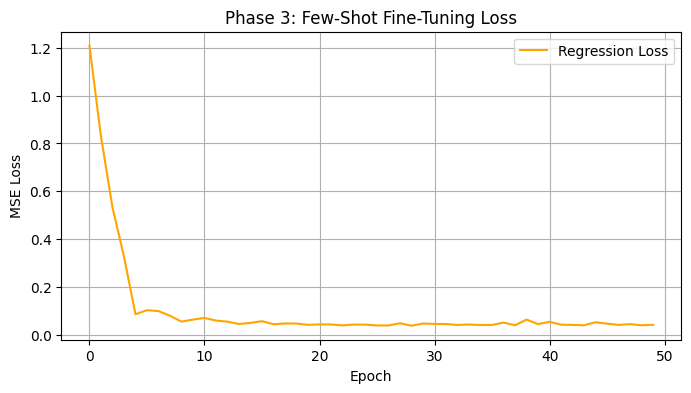

Phase 4: Test 데이터셋을 통한 성능 평가 및 Health Index 산출
Health Index 관리 상한선(UCL) 설정: 0.3073
-> Test 세트 진단/예측 결과 CSV 저장 완료


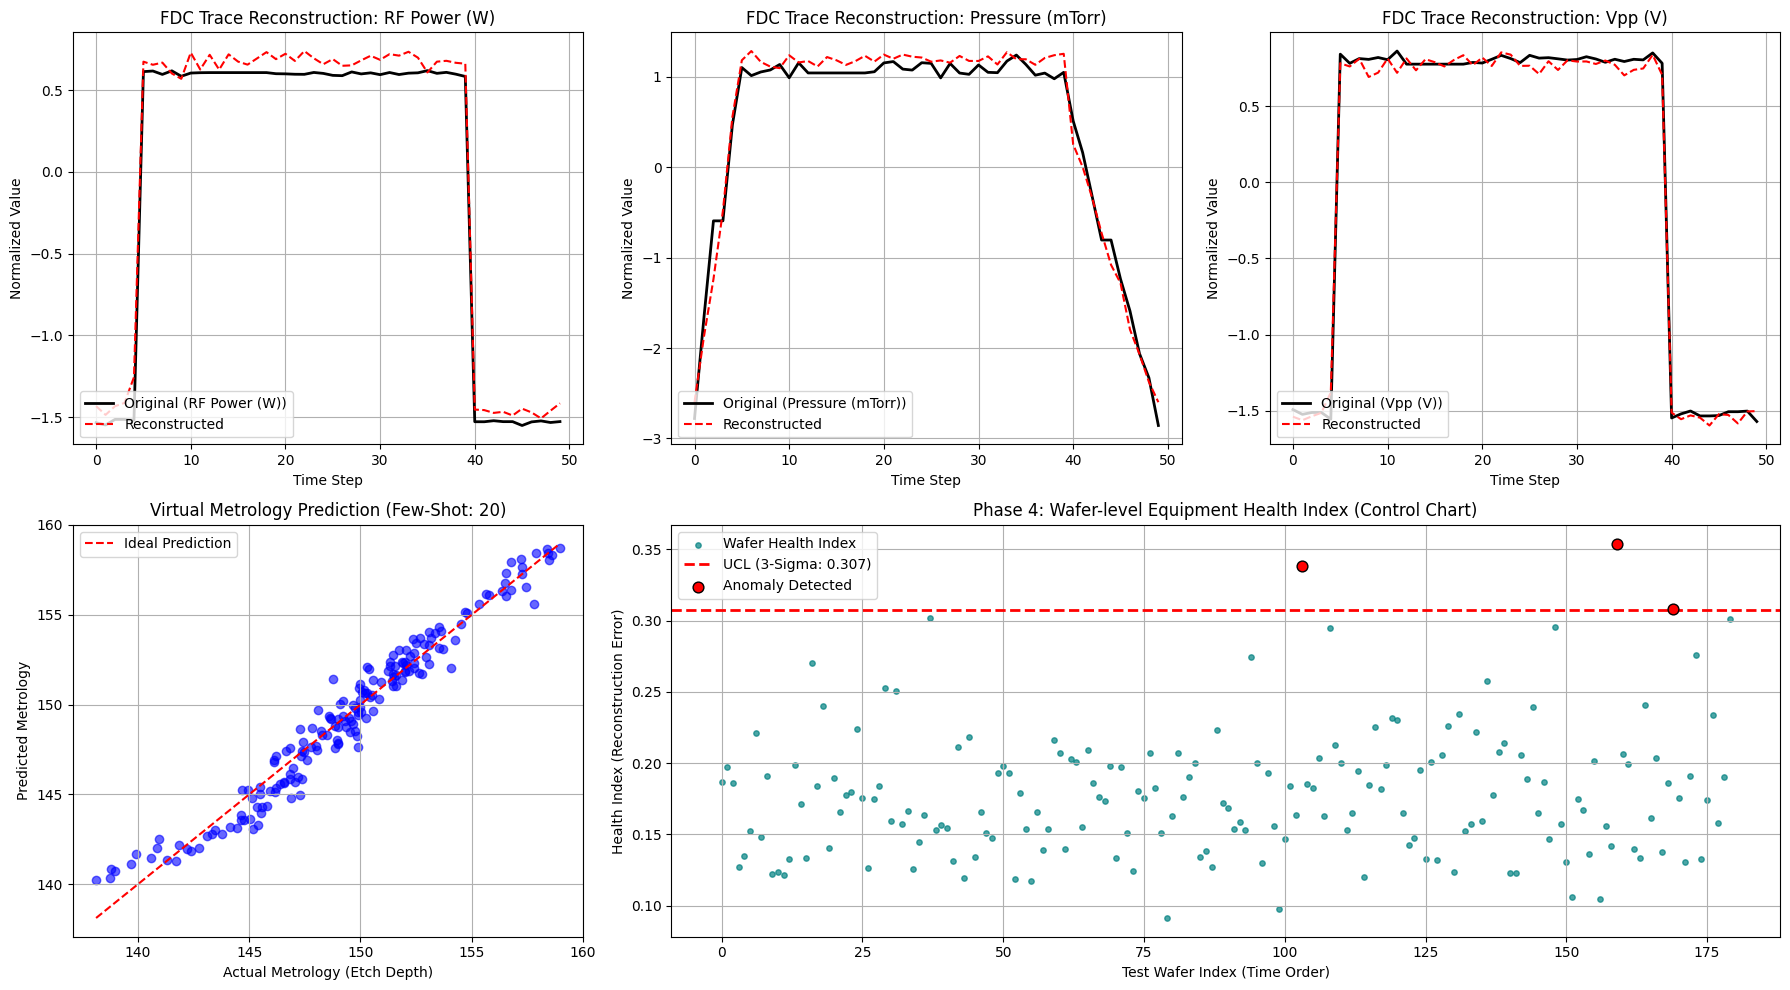

Test 세트 최종 예측 RMSE: 0.93

Phase 5: Anomaly Deep Dive (이상 원인 분석 시작)
총 3개의 이상 웨이퍼가 발견되었습니다. 모든 이상 웨이퍼에 대해 분석을 진행합니다.
이상 웨이퍼: Test Wafer #103 (Health Index: 0.3380) 분석 중...
-> 이상 웨이퍼 #103 원인 분석(Root Cause) 결과 CSV 저장 완료


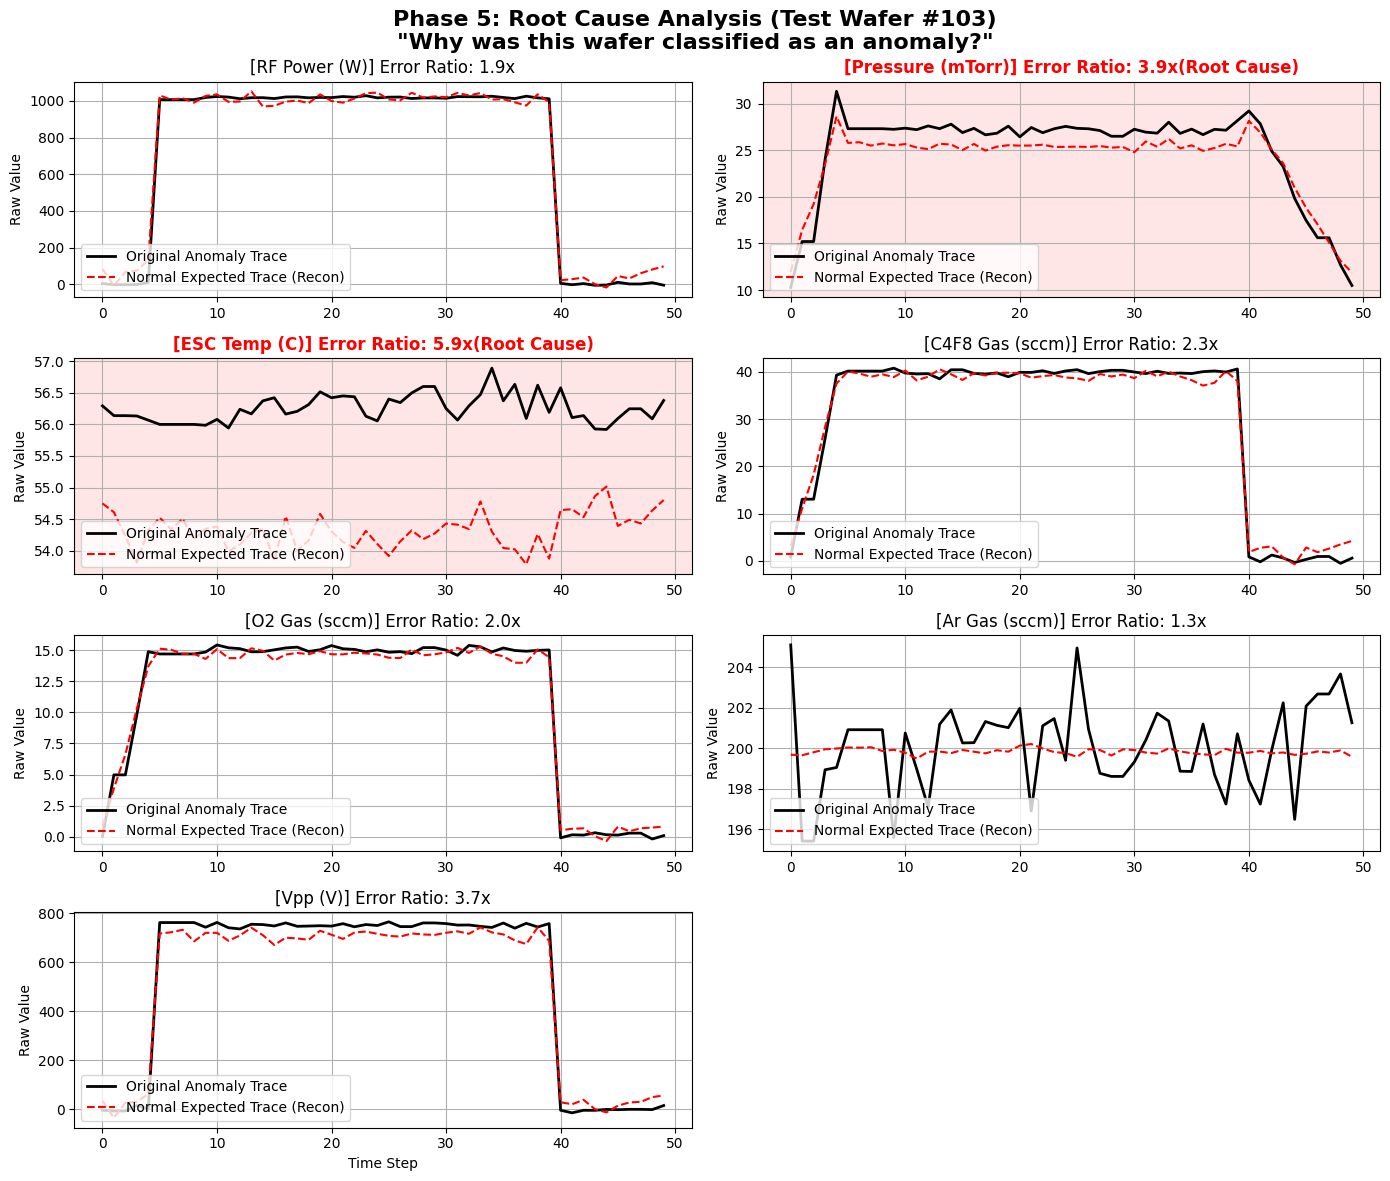

이상 웨이퍼: Test Wafer #159 (Health Index: 0.3541) 분석 중...
-> 이상 웨이퍼 #159 원인 분석(Root Cause) 결과 CSV 저장 완료


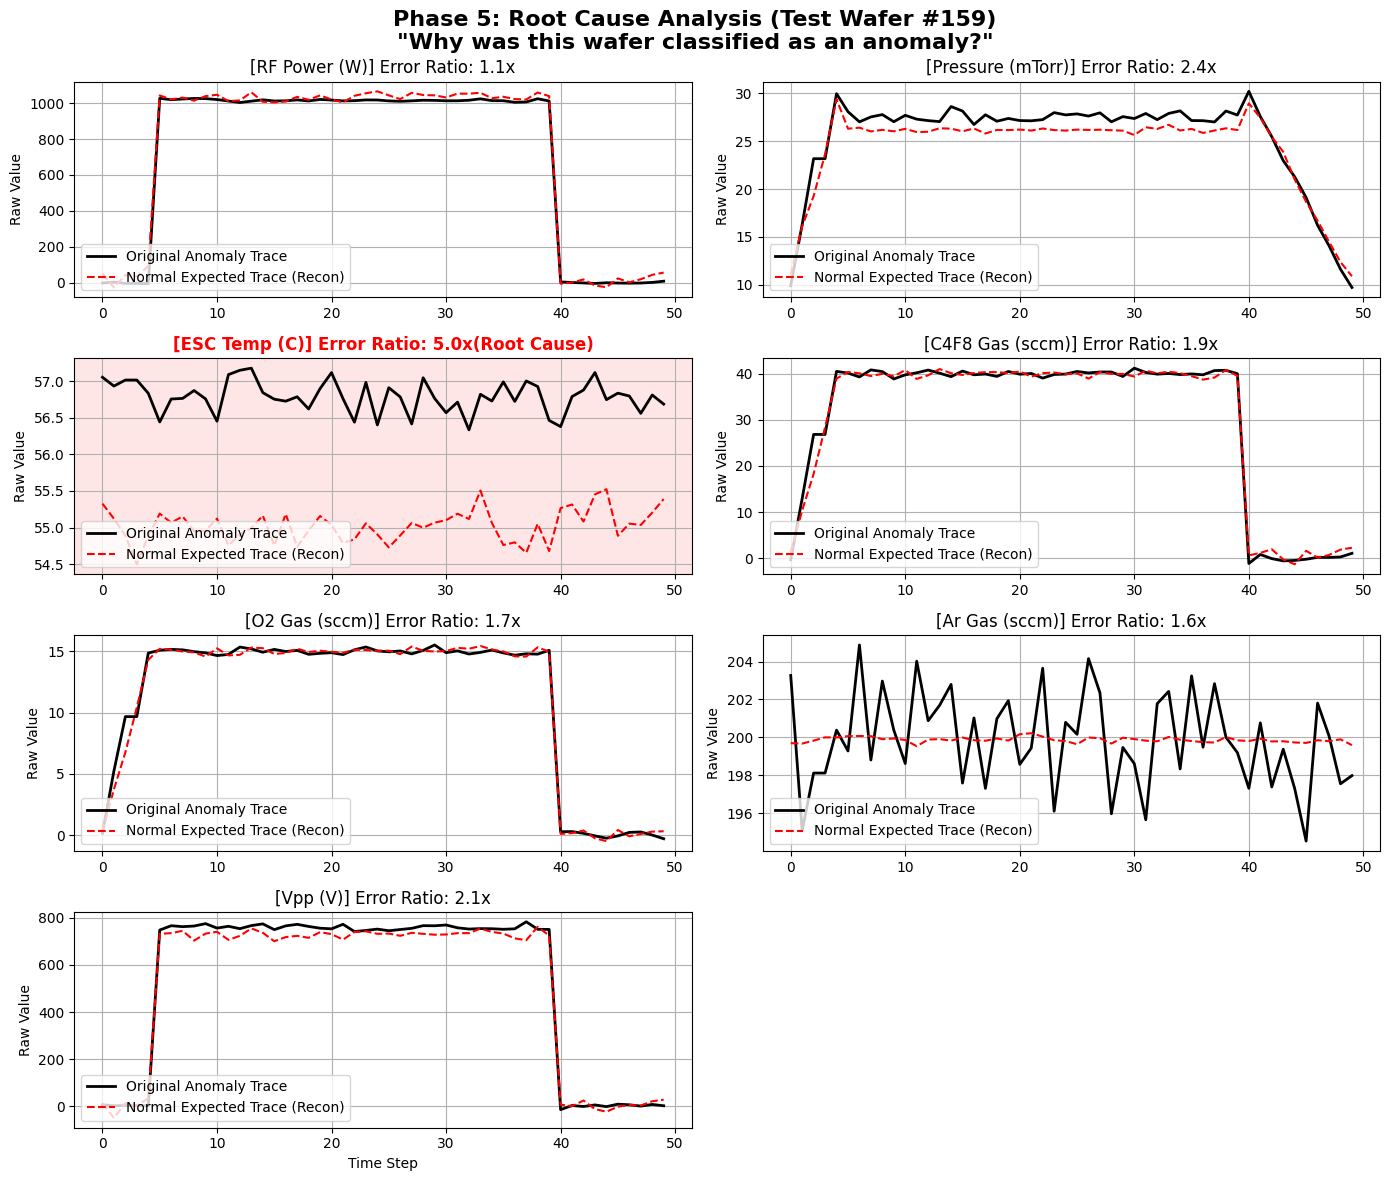

이상 웨이퍼: Test Wafer #169 (Health Index: 0.3080) 분석 중...
-> 이상 웨이퍼 #169 원인 분석(Root Cause) 결과 CSV 저장 완료


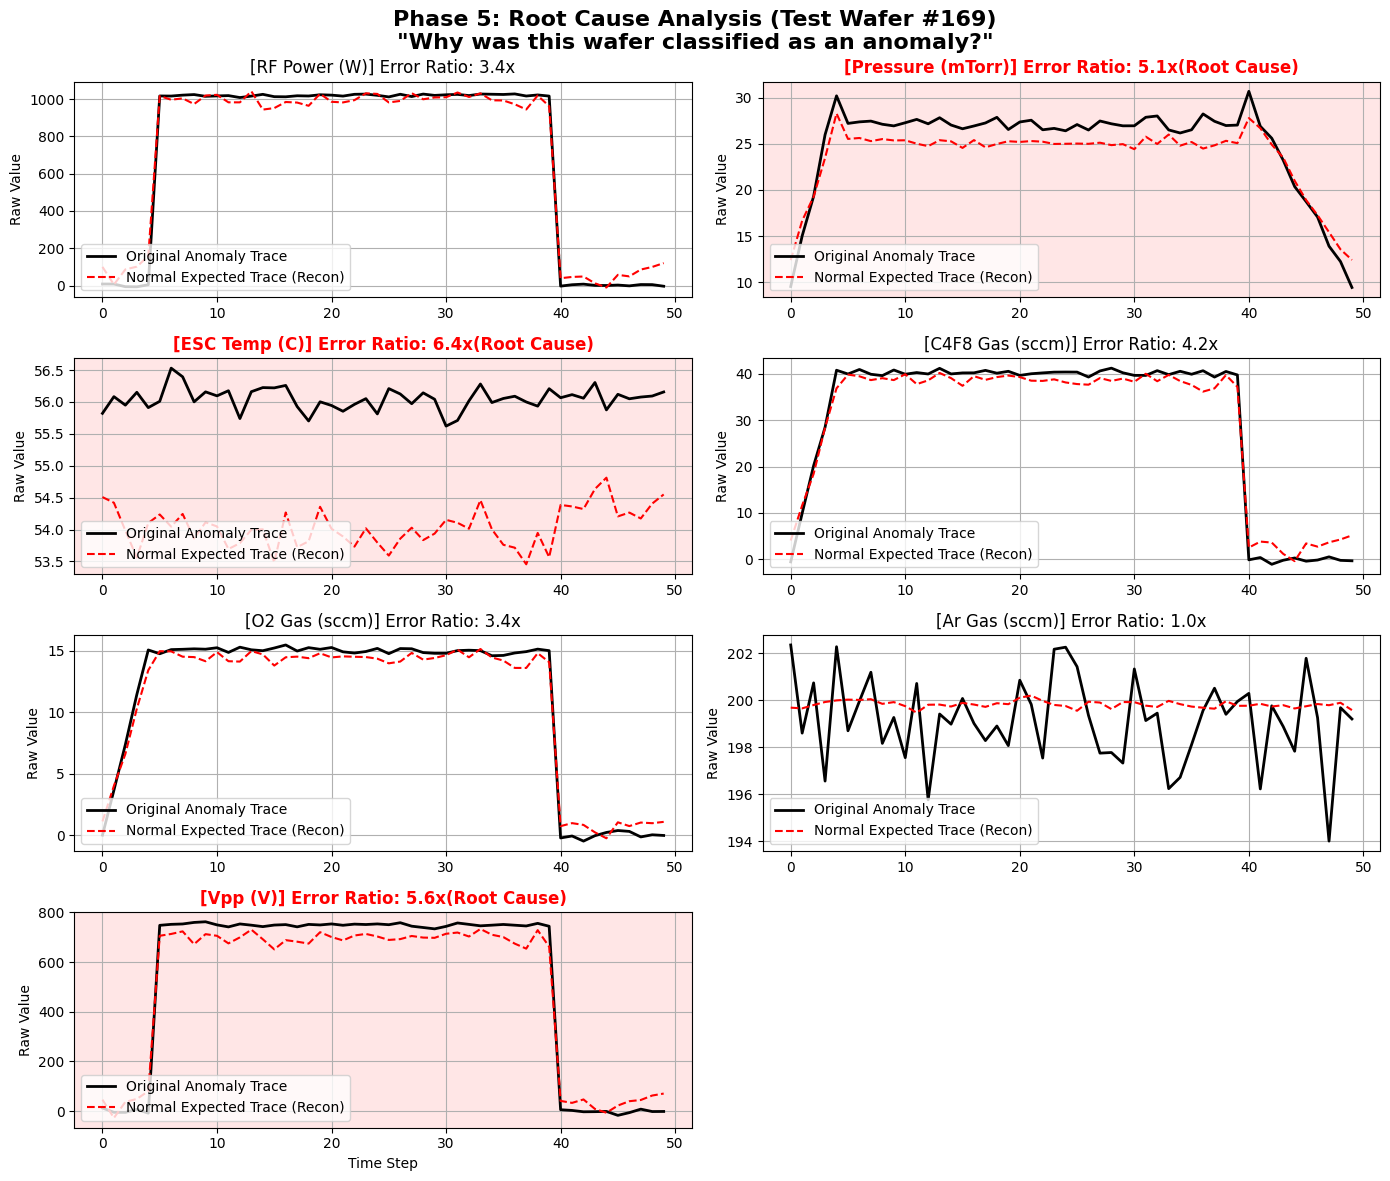

In [2]:
import numpy as np
import pandas as pd # [추가] CSV 저장을 위한 pandas 라이브러리
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import os # [추가] 디렉토리 관리를 위해 추가
import math # [추가] Transformer의 Positional Encoding을 위한 수학 모듈

# CSV 파일을 저장할 폴더 생성
output_dir = "fdc_outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# ==========================================
# Phase 1: 가상 데이터 생성 및 전처리 (Data Engineering)
# ==========================================
print("Phase 1: 데이터 생성 및 전처리 시작...")

# 하이퍼파라미터 설정
NUM_WAFERS = 1000      # 총 웨이퍼 수 (FDC 데이터)
SEQ_LENGTH = 50        # 모델에 입력될 고정된 레시피 진행 시간 (Step 수)
NUM_SENSORS = 7        # 식각 장비 센서 개수 증가 (7개)
FEW_SHOT_SIZE = 20     # 실제 계측(Label)이 존재하는 웨이퍼 수

# 식각 장비 센서 리스트
sensor_names = ['RF Power (W)', 'Pressure (mTorr)', 'ESC Temp (C)', 'C4F8 Gas (sccm)', 'O2 Gas (sccm)', 'Ar Gas (sccm)', 'Vpp (V)']

# 1. 가상 FDC Trace 데이터 및 계측(Metrology) 데이터 생성 (식각 장비 모사)
np.random.seed(42)
torch.manual_seed(42)

raw_X_data = [] # 길이가 다른 원본 데이터를 담을 리스트
y_data = []

for _ in range(NUM_WAFERS):
    # 설비의 미세한 상태 변화 (Latent Drift)를 가정 (예: 챔버 월 폴리머 누적)
    latent_drift = np.random.randn()

    # 실제 환경처럼 웨이퍼마다 공정 진행 시간이 미세하게 다름을 모사 (40 ~ 60 스텝)
    random_length = np.random.randint(40, 61)
    trace = np.zeros((random_length, NUM_SENSORS))

    # 레시피 스텝 분할
    step1_end = int(random_length * 0.1) # 스텝 1: 가스 안정화
    step2_end = int(random_length * 0.8) # 스텝 2: 메인 식각(Main Etch)

    # [0] RF Power: 메인 식각 때만 On
    trace[step1_end:step2_end, 0] = 1000 - latent_drift * 10

    # [1] Pressure: 펌핑 및 가스 주입에 따른 변화
    trace[:step1_end, 1] = np.linspace(10, 30, step1_end)
    trace[step1_end:step2_end, 1] = 30 + latent_drift * 1.5
    trace[step2_end:, 1] = np.linspace(30, 10, random_length - step2_end)

    # [2] ESC Temp (정전척 온도): 일정 유지되나 쿨링 효율 저하 반영
    trace[:, 2] = 60 + latent_drift * 2

    # [3] C4F8 Gas (주 식각 가스)
    trace[:step1_end, 3] = np.linspace(0, 40, step1_end)
    trace[step1_end:step2_end, 3] = 40

    # [4] O2 Gas (폴리머 제어용)
    trace[:step1_end, 4] = np.linspace(0, 15, step1_end)
    trace[step1_end:step2_end, 4] = 15

    # [5] Ar Gas (캐리어 및 스퍼터링) - 완전한 노이즈성 데이터 모사
    trace[:, 5] = 200

    # [6] Vpp (Peak-to-Peak Voltage): 플라즈마 임피던스 상태 (RF 파워와 동기화)
    trace[step1_end:step2_end, 6] = 800 + latent_drift * 25

    # 센서별 고유 노이즈 스케일 적용 (현실적인 노이즈 추가)
    noise_scales = [5.0, 0.5, 0.2, 0.5, 0.2, 2.0, 8.0]
    noise = np.random.randn(random_length, NUM_SENSORS) * noise_scales

    raw_X_data.append(trace + noise)

    # 계측 데이터 (Etch Depth: 기본 150nm에 Drift 반영)
    etch_depth = 150 - latent_drift * 4.5 + np.random.randn() * 0.8
    y_data.append(etch_depth)

y_data = np.array(y_data) # Shape: (1000,)

# 1-2. DTW (Dynamic Time Warping)를 이용한 데이터 정렬 및 동기화
print("DTW를 활용하여 비동기 Trace 데이터를 기준 궤적(SEQ_LENGTH)으로 정렬 중... (시간이 조금 소요될 수 있습니다)")

# 기준 궤적(Reference Trace) 생성 (Latent Drift 없는 이상적 파형)
ref_trace = np.zeros((SEQ_LENGTH, NUM_SENSORS))
r_step1 = int(SEQ_LENGTH * 0.1)
r_step2 = int(SEQ_LENGTH * 0.8)

ref_trace[r_step1:r_step2, 0] = 1000
ref_trace[:r_step1, 1] = np.linspace(10, 30, r_step1)
ref_trace[r_step1:r_step2, 1] = 30
ref_trace[r_step2:, 1] = np.linspace(30, 10, SEQ_LENGTH - r_step2)
ref_trace[:, 2] = 60
ref_trace[:r_step1, 3] = np.linspace(0, 40, r_step1)
ref_trace[r_step1:r_step2, 3] = 40
ref_trace[:r_step1, 4] = np.linspace(0, 15, r_step1)
ref_trace[r_step1:r_step2, 4] = 15
ref_trace[:, 5] = 200
ref_trace[r_step1:r_step2, 6] = 800

X_data = []
for raw_trace in raw_X_data:
    # fastdtw를 통해 기준 궤적(50스텝)과 원본 궤적(40~60스텝) 간의 최적 매핑 경로 탐색
    distance, path = fastdtw(ref_trace, raw_trace, dist=euclidean)

    aligned_trace = np.zeros_like(ref_trace)
    counts = np.zeros(SEQ_LENGTH)

    # 매핑된 경로를 따라 값 할당 (예: 원본의 여러 스텝이 기준의 한 스텝에 매핑될 경우 평균 처리)
    for ref_idx, raw_idx in path:
        aligned_trace[ref_idx] += raw_trace[raw_idx]
        counts[ref_idx] += 1

    aligned_trace = aligned_trace / counts[:, np.newaxis]
    X_data.append(aligned_trace)

X_data = np.array(X_data) # 비로소 모든 데이터가 Shape: (1000, 50, 7)으로 통일됨

# ==========================================
# [CSV 저장] 1 & 2: 원본 Trace 및 Metrology 데이터
# ==========================================
# 1. 시계열 Trace 데이터 저장 (3D -> 2D 변환)
# 설명: 모든 웨이퍼의 Time Step별 7개 센서 값을 기록한 시계열 데이터셋
trace_records = []
for w_idx in range(NUM_WAFERS):
    for t_idx in range(SEQ_LENGTH):
        record = [w_idx, t_idx] + X_data[w_idx, t_idx, :].tolist()
        trace_records.append(record)
df_trace = pd.DataFrame(trace_records, columns=['Wafer_ID', 'Time_Step'] + sensor_names)
df_trace.to_csv(os.path.join(output_dir, '01_sample_fdc_trace_data.csv'), index=False)

# 2. Metrology (계측) 데이터 저장
# 설명: 각 웨이퍼별 최종 식각 깊이(Etch Depth) Label 값
df_metrology = pd.DataFrame({'Wafer_ID': range(NUM_WAFERS), 'Etch_Depth_nm': y_data})
df_metrology.to_csv(os.path.join(output_dir, '02_sample_metrology_data.csv'), index=False)
print(f"-> 샘플 데이터 CSV 저장 완료 ({output_dir}/ 폴더)")


# 2. 데이터 분할 (Pre-training / Few-shot / Test)
# - Unlabeled (Pre-training): 800개
# - Labeled (Few-shot): 20개
# - Test: 180개
X_pretrain = X_data[:800]
X_fewshot = X_data[800:800+FEW_SHOT_SIZE]
y_fewshot = y_data[800:800+FEW_SHOT_SIZE]
X_test = X_data[800+FEW_SHOT_SIZE:]
y_test = y_data[800+FEW_SHOT_SIZE:]

# 3. 데이터 정규화 (Standard Scaling)
scaler = StandardScaler()
# 시계열 데이터를 2D로 펼쳐서 스케일링 후 다시 3D로 복구
X_pretrain_scaled = scaler.fit_transform(X_pretrain.reshape(-1, NUM_SENSORS)).reshape(X_pretrain.shape)
X_fewshot_scaled = scaler.transform(X_fewshot.reshape(-1, NUM_SENSORS)).reshape(X_fewshot.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, NUM_SENSORS)).reshape(X_test.shape)

# 타겟(y) 데이터 정규화 (Regression 딥러닝 모델의 필수 과정)
y_scaler = StandardScaler()
y_fewshot_scaled = y_scaler.fit_transform(y_fewshot.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

# PyTorch Tensor 변환 및 DataLoader 생성
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_pretrain_scaled)), batch_size=64, shuffle=True)
fewshot_loader = DataLoader(TensorDataset(torch.FloatTensor(X_fewshot_scaled), torch.FloatTensor(y_fewshot_scaled)), batch_size=4, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test_scaled), torch.FloatTensor(y_test_scaled)), batch_size=32, shuffle=False)

print(f"데이터 준비 완료! Pre-train: {len(X_pretrain)}개, Few-shot: {len(X_fewshot)}개, Test: {len(X_test)}개\n")

# Phase 1 결과 시각화 (센서가 7개로 늘어나 4x2 Grid 형태로 시각화)
fig, axs = plt.subplots(4, 2, figsize=(14, 10))
fig.suptitle('Phase 1: Sample Etch FDC Raw Trace Data (1st Wafer)', fontsize=16)
axs = axs.flatten()
for i in range(NUM_SENSORS):
    # 원본 길이가 다른 날 것 그대로의 형태(DTW 전) 시각화
    axs[i].plot(raw_X_data[0][:, i], label=f'{sensor_names[i]}', color='C'+str(i))
    axs[i].set_ylabel('Value')
    axs[i].legend(loc='upper right')
    axs[i].grid(True)

axs[-2].set_xlabel('Time Step')
axs[-1].axis('off') # 남는 8번째 subplot 숨기기
plt.tight_layout()
plt.show()

# ==========================================
# 모델 아키텍처 정의 (Transformer Autoencoder & Regressor)
# ==========================================
class PositionalEncoding(nn.Module):
    """Transformer에 시계열의 시간(Step) 순서 정보를 주입하는 모듈"""
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:x.size(1), :].unsqueeze(0)
        return x

class FDCEncoder(nn.Module):
    """다변량 센서 데이터를 입력받아 압축된 Latent Vector를 생성하는 Transformer 인코더"""
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, latent_dim=16):
        super(FDCEncoder, self).__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)

        self.fc_latent = nn.Linear(d_model, latent_dim)

    def forward(self, x):
        # 1. 입력 차원을 d_model(64) 크기로 투영하고 위치 정보를 더함
        x = self.input_proj(x)
        x = self.pos_encoder(x)

        # 2. Transformer 인코더 통과 (Self-Attention)
        x = self.transformer_encoder(x)

        # 3. 전체 시퀀스(50스텝)의 정보를 하나로 요약하기 위해 Global Average Pooling 수행
        x_mean = x.mean(dim=1)

        # 4. Latent Vector (16차원)으로 압축
        latent = self.fc_latent(x_mean)
        return latent

class FDCDecoder(nn.Module):
    """Latent Vector로부터 원래의 시계열 궤적을 복원하는 Transformer 디코더"""
    def __init__(self, latent_dim, d_model=64, nhead=4, num_layers=2, output_dim=7, seq_len=50):
        super(FDCDecoder, self).__init__()
        self.seq_len = seq_len

        # Latent Vector를 (시퀀스 길이 * d_model) 크기로 확장
        self.latent_proj = nn.Linear(latent_dim, d_model * self.seq_len)
        self.pos_encoder = PositionalEncoding(d_model)

        decoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_decoder = nn.TransformerEncoder(decoder_layers, num_layers=num_layers)

        # d_model 크기를 원래의 센서 개수(7)로 복원
        self.fc_out = nn.Linear(d_model, output_dim)

    def forward(self, latent):
        batch_size = latent.size(0)

        # 1. 1차원 Latent 벡터를 다시 시퀀스 형태(batch_size, seq_len, d_model)로 변환
        x = self.latent_proj(latent)
        x = x.view(batch_size, self.seq_len, -1)

        # 2. 위치 정보 주입 및 Transformer 통과
        x = self.pos_encoder(x)
        x = self.transformer_decoder(x)

        # 3. 최종 센서 값으로 투영
        reconstruction = self.fc_out(x)
        return reconstruction

class FDCFoundationModel(nn.Module):
    """정상 FDC 데이터를 복원하는 Transformer 기반 Autoencoder 모델 (Pre-training 용)"""
    def __init__(self, input_dim=NUM_SENSORS, d_model=64, latent_dim=16, seq_len=50):
        super(FDCFoundationModel, self).__init__()
        self.encoder = FDCEncoder(input_dim, d_model=d_model, latent_dim=latent_dim)
        self.decoder = FDCDecoder(latent_dim, d_model=d_model, output_dim=input_dim, seq_len=seq_len)

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction

class FDCVirtualMetrologyModel(nn.Module):
    """사전 학습된 인코더에 Regression Head를 붙인 모델 (Few-shot/Predictive 용)"""
    def __init__(self, encoder):
        super(FDCVirtualMetrologyModel, self).__init__()
        self.encoder = encoder
        # 계측치 예측을 위한 Regression Head
        self.regressor = nn.Sequential(
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        latent = self.encoder(x)
        prediction = self.regressor(latent)
        return prediction.squeeze(-1) # 차원 축소를 마지막 차원으로 명시하여 안정성 확보


# ==========================================
# Phase 2: Foundation Model 사전 학습 (Pre-training)
# ==========================================
print("Phase 2: Foundation Model (Transformer Autoencoder) 사전 학습 시작...")
foundation_model = FDCFoundationModel(input_dim=NUM_SENSORS)
criterion_reconstruction = nn.MSELoss()

# [수정] Transformer 구조는 더 섬세한 학습이 필요하므로 학습률(lr)을 0.005에서 0.001로 조정
optimizer_pretrain = optim.Adam(foundation_model.parameters(), lr=0.001)

EPOCHS_PRETRAIN = 30
pretrain_losses = []

for epoch in range(EPOCHS_PRETRAIN):
    foundation_model.train()
    total_loss = 0
    for (batch_x,) in train_loader:
        optimizer_pretrain.zero_grad()
        reconstruction = foundation_model(batch_x)
        loss = criterion_reconstruction(reconstruction, batch_x) # 입력값을 그대로 복원(Self-supervised)
        loss.backward()
        optimizer_pretrain.step()
        total_loss += loss.item()

    avg_loss = total_loss/len(train_loader)
    pretrain_losses.append(avg_loss)

    if (epoch+1) % 10 == 0:
        print(f"Pre-train Epoch [{epoch+1}/{EPOCHS_PRETRAIN}], Loss: {avg_loss:.4f}")

# ==========================================
# [CSV 저장] 3. Phase 2 Pre-train 학습 곡선 데이터
# ==========================================
# 설명: Foundation Model이 에폭별로 장비 정상상태를 학습하며 떨어진 복원 오차(MSE Loss) 추이
df_pretrain_loss = pd.DataFrame({'Epoch': range(1, EPOCHS_PRETRAIN + 1), 'Reconstruction_Loss': pretrain_losses})
df_pretrain_loss.to_csv(os.path.join(output_dir, '03_phase2_pretrain_loss.csv'), index=False)
print("Pre-training 완료 및 학습 곡선 저장 완료!\n")

# Phase 2 학습 곡선 시각화
plt.figure(figsize=(8, 4))
plt.plot(pretrain_losses, label='Reconstruction Loss', color='blue')
plt.title('Phase 2: Foundation Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


# ==========================================
# Phase 3: Few-Shot Learning (미세 조정 - Fine-Tuning)
# ==========================================
print("Phase 3: 소수 계측 데이터를 활용한 Foundation Model Fine-Tuning 시작...")
# 사전학습된 Encoder를 가져와서 예측 모델 생성
vm_model = FDCVirtualMetrologyModel(encoder=foundation_model.encoder)

# Encoder의 파라미터 동결을 해제하여 전체 모델이 Fine-tuning 되도록 합니다.
for param in vm_model.encoder.parameters():
    param.requires_grad = True

criterion_regression = nn.MSELoss()

# 차등 학습률(Differential Learning Rate) 적용
optimizer_fewshot = optim.Adam([
    {'params': vm_model.encoder.parameters(), 'lr': 0.0001},
    {'params': vm_model.regressor.parameters(), 'lr': 0.01}
])

EPOCHS_FEWSHOT = 50
fewshot_losses = []

for epoch in range(EPOCHS_FEWSHOT):
    vm_model.train()
    total_loss = 0
    for batch_x, batch_y in fewshot_loader:
        optimizer_fewshot.zero_grad()
        prediction = vm_model(batch_x)
        loss = criterion_regression(prediction, batch_y)
        loss.backward()
        optimizer_fewshot.step()
        total_loss += loss.item()

    avg_loss = total_loss/len(fewshot_loader)
    fewshot_losses.append(avg_loss)

    if (epoch+1) % 10 == 0:
        print(f"Few-Shot Epoch [{epoch+1}/{EPOCHS_FEWSHOT}], Loss: {avg_loss:.4f}")

# ==========================================
# [CSV 저장] 4. Phase 3 Fine-tuning 학습 곡선 데이터
# ==========================================
# 설명: 소수의 Label 데이터를 통해 예측 모델(VM)이 에폭별로 적응한 회귀 오차 추이
df_fewshot_loss = pd.DataFrame({'Epoch': range(1, EPOCHS_FEWSHOT + 1), 'Regression_Loss': fewshot_losses})
df_fewshot_loss.to_csv(os.path.join(output_dir, '04_phase3_fewshot_loss.csv'), index=False)
print("Few-Shot Fine-tuning 완료 및 학습 곡선 저장 완료!\n")

# Phase 3 파인튜닝 학습 곡선 시각화
plt.figure(figsize=(8, 4))
plt.plot(fewshot_losses, label='Regression Loss', color='orange')
plt.title('Phase 3: Few-Shot Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


# ==========================================
# Phase 4: 평가 및 시각화 (진단 및 예측)
# ==========================================
print("Phase 4: Test 데이터셋을 통한 성능 평가 및 Health Index 산출")
foundation_model.eval()
vm_model.eval()

# --- Health Index 관리를 위한 정상 데이터 기준선(UCL) 계산 ---
train_errors = []
train_errors_per_sensor = [] # Phase 5를 위한 센서별 정상 Baseline 오차 수집

with torch.no_grad():
    for (batch_x,) in train_loader:
        recon = foundation_model(batch_x)
        mse = torch.mean((recon - batch_x)**2, dim=[1, 2]).numpy()
        train_errors.extend(mse)
        mse_sensor = torch.mean((recon - batch_x)**2, dim=1).numpy()
        train_errors_per_sensor.extend(mse_sensor)

# 3-Sigma 규칙을 이용한 Upper Control Limit (UCL) 설정
ucl_threshold = np.mean(train_errors) + 3 * np.std(train_errors)
print(f"Health Index 관리 상한선(UCL) 설정: {ucl_threshold:.4f}")

# 정상 웨이퍼들의 센서별 평균 오차(Baseline) 계산
normal_sensor_mses = np.mean(train_errors_per_sensor, axis=0)

test_predictions = []
test_actuals = []
test_health_indices = [] # Test 웨이퍼별 Health Index 저장
sample_original = None
sample_reconstructed = None

with torch.no_grad():
    for i, (batch_x, batch_y) in enumerate(test_loader):
        # 1. 진단 (Reconstruction Error 파악 -> Health Index 도출)
        reconstruction = foundation_model(batch_x)
        batch_mse = torch.mean((reconstruction - batch_x)**2, dim=[1, 2]).numpy()
        test_health_indices.extend(batch_mse)

        if sample_original is None:
            sample_original = batch_x[0].numpy()
            sample_reconstructed = reconstruction[0].numpy()

        # 2. 예측 (Virtual Metrology)
        preds = vm_model(batch_x)
        test_predictions.extend(preds.numpy())
        test_actuals.extend(batch_y.numpy())

# 스케일링된 예측값과 실제값을 원래 두께(Thickness) 스케일로 복원
test_predictions = y_scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1)).flatten()
test_actuals = y_scaler.inverse_transform(np.array(test_actuals).reshape(-1, 1)).flatten()

# 이상치(UCL 초과) 여부 기록
outliers = np.where(np.array(test_health_indices) > ucl_threshold)[0]

# ==========================================
# [CSV 저장] 5. Test 웨이퍼 진단 및 예측 최종 결과 모음
# ==========================================
# 설명: Test 데이터셋 180장에 대한 실제 계측값, VM 예측값, 계산된 Health Index 및 불량 여부 정리
df_test_results = pd.DataFrame({
    'Test_Wafer_Idx': range(len(test_actuals)),
    'Actual_Etch_Depth': test_actuals,
    'Predicted_Etch_Depth': test_predictions,
    'Health_Index': test_health_indices,
    'Is_Anomaly': [True if idx in outliers else False for idx in range(len(test_health_indices))]
})
df_test_results.to_csv(os.path.join(output_dir, '05_phase4_test_results.csv'), index=False)
print("-> Test 세트 진단/예측 결과 CSV 저장 완료")


# 시각화 (GridSpec을 사용하여 모든 센서와 예측, Health Index를 한 눈에 볼 수 있도록 구성)
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

# Plot 1: Foundation Model의 궤적 복원 능력 (주요 센서 3개 선별)
rep_sensor_indices = [0, 1, 6] # RF Power, Pressure, Vpp
for plot_idx, sensor_idx in enumerate(rep_sensor_indices):
    ax = fig.add_subplot(gs[0, plot_idx])
    ax.plot(sample_original[:, sensor_idx], label=f'Original ({sensor_names[sensor_idx]})', color='black', linewidth=2)
    ax.plot(sample_reconstructed[:, sensor_idx], label='Reconstructed', color='red', linestyle='--')
    ax.set_title(f'FDC Trace Reconstruction: {sensor_names[sensor_idx]}')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Normalized Value')
    ax.legend(loc='lower left')
    ax.grid(True)

# Plot 2: Few-Shot 모델의 가상 계측 (Virtual Metrology) 성능
ax_vm = fig.add_subplot(gs[1, 0])
ax_vm.scatter(test_actuals, test_predictions, color='blue', alpha=0.6)
min_val = min(min(test_actuals), min(test_predictions))
max_val = max(max(test_actuals), max(test_predictions))
ax_vm.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Prediction')
ax_vm.set_title(f'Virtual Metrology Prediction (Few-Shot: {FEW_SHOT_SIZE})')
ax_vm.set_xlabel('Actual Metrology (Etch Depth)')
ax_vm.set_ylabel('Predicted Metrology')
ax_vm.legend()
ax_vm.grid(True)

# Plot 3: 웨이퍼별 Health Index 모니터링 (Scatter 차트로 변경)
ax_hi = fig.add_subplot(gs[1, 1:3]) # Health Index 차트를 더 넓게 배치

# Scatter plot으로 웨이퍼 인덱스 시각화
ax_hi.scatter(range(len(test_health_indices)), test_health_indices, color='teal', s=15, alpha=0.7, label='Wafer Health Index')
ax_hi.axhline(y=ucl_threshold, color='red', linestyle='--', linewidth=2, label=f'UCL (3-Sigma: {ucl_threshold:.3f})')

# 이상치(UCL 초과) 포인트 빨간색으로 강조
if len(outliers) > 0:
    ax_hi.scatter(outliers, np.array(test_health_indices)[outliers], color='red', s=60, zorder=5, edgecolors='black', label='Anomaly Detected')

ax_hi.set_title('Phase 4: Wafer-level Equipment Health Index (Control Chart)')
ax_hi.set_xlabel('Test Wafer Index (Time Order)')
ax_hi.set_ylabel('Health Index (Reconstruction Error)')
ax_hi.legend()
ax_hi.grid(True)

plt.tight_layout()
plt.show()

# 정량적 평가 (RMSE)
rmse = np.sqrt(np.mean((np.array(test_actuals) - np.array(test_predictions))**2))
print(f"Test 세트 최종 예측 RMSE: {rmse:.2f}")

# ==========================================
# Phase 5: Anomaly Deep Dive (이상 원인 분석)
# ==========================================
print("\nPhase 5: Anomaly Deep Dive (이상 원인 분석 시작)")

if len(outliers) > 0:
    print(f"총 {len(outliers)}개의 이상 웨이퍼가 발견되었습니다. 모든 이상 웨이퍼에 대해 분석을 진행합니다.")

    # [수정] 탐지된 모든 이상 웨이퍼(outliers)에 대해 루프를 돌며 각각 시각화 및 CSV 저장 수행
    for anomaly_idx in outliers:
        print(f"이상 웨이퍼: Test Wafer #{anomaly_idx} (Health Index: {test_health_indices[anomaly_idx]:.4f}) 분석 중...")

        # 해당 웨이퍼의 입력 데이터 (정규화된 상태) 추출
        anomaly_tensor = torch.FloatTensor(X_test_scaled[anomaly_idx]).unsqueeze(0)

        foundation_model.eval()
        with torch.no_grad():
            anomaly_recon = foundation_model(anomaly_tensor)

        anomaly_original_np = anomaly_tensor.squeeze(0).numpy()
        anomaly_recon_np = anomaly_recon.squeeze(0).numpy()

        # 7개 센서 각각에 대한 Reconstruction Error (MSE) 계산
        anomaly_sensor_mses = np.mean((anomaly_original_np - anomaly_recon_np)**2, axis=0)

        # 절대 오차가 아닌 '정상 오차(Baseline) 대비 오차 증가율(Ratio)' 계산!
        error_ratio = anomaly_sensor_mses / normal_sensor_mses
        ratio_threshold = np.mean(error_ratio) + 0.5 * np.std(error_ratio)

        # ==========================================
        # [CSV 저장] 6. 이상 웨이퍼 원인 분석(Root Cause) 결과
        # ==========================================
        # 설명: 특정 불량 웨이퍼에 대해 센서별로 정상 시 오차와 불량 시 오차, 그리고 증가 비율 기록
        df_root_cause = pd.DataFrame({
            'Sensor_Name': sensor_names,
            'Normal_Baseline_MSE': normal_sensor_mses,
            'Anomaly_MSE': anomaly_sensor_mses,
            'Error_Ratio': error_ratio,
            'Is_Root_Cause': [ratio > ratio_threshold for ratio in error_ratio]
        })
        df_root_cause.to_csv(os.path.join(output_dir, f'06_phase5_root_cause_wafer_{anomaly_idx}.csv'), index=False)
        print(f"-> 이상 웨이퍼 #{anomaly_idx} 원인 분석(Root Cause) 결과 CSV 저장 완료")

        # 시각화를 위해 정규화된 데이터를 다시 Raw 데이터(원래 스케일)로 복원
        raw_anomaly_original_np = scaler.inverse_transform(anomaly_original_np)
        raw_anomaly_recon_np = scaler.inverse_transform(anomaly_recon_np)

        # 시각화
        fig, axs = plt.subplots(4, 2, figsize=(14, 12))
        fig.suptitle(f'Phase 5: Root Cause Analysis (Test Wafer #{anomaly_idx})\n"Why was this wafer classified as an anomaly?"', fontsize=16, fontweight='bold')
        axs = axs.flatten()

        for i in range(NUM_SENSORS):
            # 복원된 Raw 데이터로 플롯 그리기
            axs[i].plot(raw_anomaly_original_np[:, i], label='Original Anomaly Trace', color='black', linewidth=2)
            axs[i].plot(raw_anomaly_recon_np[:, i], label='Normal Expected Trace (Recon)', color='red', linestyle='--')

            # 오차 증가율이 기준을 넘는 센서만 Root Cause로 판별
            is_root_cause = error_ratio[i] > ratio_threshold
            title_color = 'red' if is_root_cause else 'black'
            weight = 'bold' if is_root_cause else 'normal'

            # 타이틀에 증가율(Ratio) 명시 (예: 평소보다 몇 배 오차가 큰가?)
            title_text = f'[{sensor_names[i]}] Error Ratio: {error_ratio[i]:.1f}x'
            if is_root_cause:
                title_text += '(Root Cause)'

            axs[i].set_title(title_text, color=title_color, fontweight=weight)
            axs[i].set_ylabel('Raw Value')
            axs[i].legend(loc='lower left')
            axs[i].grid(True)

            # 불량의 원인인 센서 그래프의 배경을 살짝 붉게 칠하여 엔지니어의 시선을 유도
            if is_root_cause:
                axs[i].set_facecolor('#ffe6e6')

        axs[-2].set_xlabel('Time Step')
        axs[-1].axis('off') # 남는 8번째 subplot 숨기기
        plt.tight_layout()
        plt.show()

else:
    print("UCL을 초과하는 이상 웨이퍼가 발견되지 않아 Deep Dive를 생략합니다.")